# Image-Based Fire and Smoke Detection Using Image Processing and Deep Learning

**ARTI 404 — Image Processing — Group 3**

**Authors:** Amal Saad Alghamdi, Sadeem Ayman AlTurki, Layan Abdulaziz Alomair, Rimas Yousif Alajmi, Maryam Amr Alghamdi, Eman Yassen Alsadh

---

## Notebook Overview

This notebook implements a complete fire and smoke detection pipeline that combines **classical image processing** with a **deep learning classifier**. It is organized in 11 sections that mirror the research paper:

1. Environment setup and reproducibility
2. Dataset loading (Kaggle fire/smoke/non-fire images)
3. Exploratory data analysis (EDA)
4. Image preprocessing pipeline (resize, normalize, histogram equalization, Gaussian/median filtering)
5. Classical image processing baseline (HSV + RGB thresholding, morphology, edge detection)
6. Data augmentation strategy
7. CNN model — custom architecture + transfer learning options (MobileNetV2 / ResNet50 / EfficientNet)
8. Training loop with callbacks (early stopping, checkpoints, LR reduction)
9. Evaluation (accuracy / precision / recall / F1 / confusion matrix / ROC)
10. Inference on new images and real-time webcam detection
11. Saving the final model for deployment

> **Why hybrid?** Classical methods (HSV/RGB color rules from Celik & Demirel [5], Toreyin et al. [6]) are fast and interpretable but produce false positives on sunsets and orange objects. CNN features (Li & Zhao [1], Prakash et al. [2], Elhanashi et al. [4]) are more robust but heavier. We use the classical pipeline as a fast pre-filter and the CNN as the final classifier.


## 1. Environment Setup

Install required packages (uncomment the first line if running for the first time). All seeds are fixed so results are reproducible.

In [3]:
!pip install tensorflow opencv-python scikit-learn matplotlib seaborn pillow tqdm

import os
import random
import warnings
import sys
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.applications import MobileNetV2, ResNet50, EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_recall_fscore_support
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# GPU check
gpus = tf.config.list_physical_devices("GPU")
print("TensorFlow:", tf.__version__)
print("GPUs detected:", len(gpus))
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Memory growth enabled on all GPUs.")
    except Exception as e:
        print("Could not set memory growth:", e)
else:
    print("Running on CPU. Training will be slower; reduce EPOCHS if needed.")

print(sys.executable)



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


TensorFlow: 2.21.0
GPUs detected: 0
Running on CPU. Training will be slower; reduce EPOCHS if needed.
c:\Users\user\AppData\Local\Programs\Python\Python311\python.exe


## 2. Configuration

All tunable hyperparameters live here. Modify these values to experiment.

In [4]:
# ---- Paths ----
DATA_DIR = Path("data/fire_dataset")   # Expected structure: data/fire_dataset/{fire,smoke,non_fire}/
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR = OUTPUT_DIR / "models"
MODEL_DIR.mkdir(exist_ok=True)
FIG_DIR = OUTPUT_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

# ---- Image parameters ----
IMG_SIZE   = 224          # Square input for CNNs
CHANNELS   = 3
BATCH_SIZE = 32

# ---- Training ----
EPOCHS         = 30
LEARNING_RATE  = 1e-4
VALIDATION_SPLIT = 0.15   # 15% val, 15% test, 70% train
TEST_SPLIT       = 0.15

# ---- Classes ----
CLASSES = ["non_fire", "fire"]  # 2-class classification
NUM_CLASSES = len(CLASSES)

# ---- Choice of backbone (set to 'custom' to use scratch CNN) ----
BACKBONE = "mobilenetv2"   # one of: "custom", "mobilenetv2", "resnet50", "efficientnetb0"

print(f"Image size: {IMG_SIZE}x{IMG_SIZE}, batch size: {BATCH_SIZE}")
print(f"Classes: {CLASSES}")
print(f"Backbone: {BACKBONE}")


Image size: 224x224, batch size: 32
Classes: ['non_fire', 'fire']
Backbone: mobilenetv2


## 3. Dataset Loading & EDA

We expect the Kaggle dataset to be unzipped into `data/fire_dataset/` with one subfolder per class. If your dataset only has two classes (fire / non_fire), set `CLASSES = ["non_fire", "fire"]` in the config cell above and `NUM_CLASSES = 2`.

The helper below walks the directory and collects all image paths with their labels.

In [5]:
def collect_image_paths(data_dir: Path, classes):
    #Return a DataFrame of image paths with their integer labels.
    records = []
    for label_idx, cls in enumerate(classes):
        cls_dir = data_dir / cls
        if not cls_dir.exists():
            print(f"[WARN] Missing class folder: {cls_dir}")
            continue
        for img_path in cls_dir.rglob("*"):
            if img_path.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}:
                records.append({"path": str(img_path), "label": label_idx, "class": cls})
    df = pd.DataFrame(records)
    return df.sample(frac=1, random_state=SEED).reset_index(drop=True)

# This will only succeed once you place the Kaggle data under DATA_DIR.
if DATA_DIR.exists():
    df = collect_image_paths(DATA_DIR, CLASSES)
    print(f"Total images: {len(df)}")
    print(df["class"].value_counts())
else:
    print(f"[INFO] {DATA_DIR} not found yet. Download the Kaggle dataset and extract it there.")
    df = pd.DataFrame(columns=["path", "label", "class"])


Total images: 999
class
fire        755
non_fire    244
Name: count, dtype: int64


### 3.1 Class distribution

A balanced dataset is desirable. If one class dominates, we will (a) use class weights during training and/or (b) oversample the minority class with augmentation.

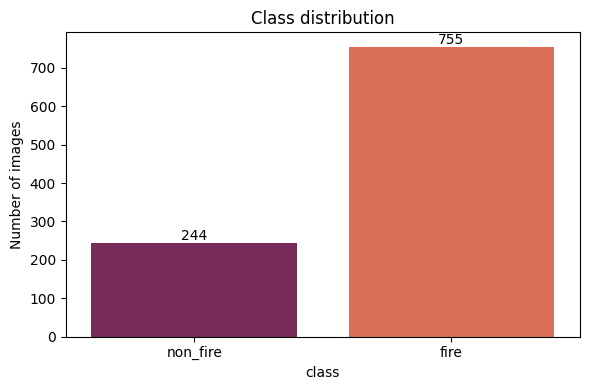

In [6]:
if len(df) > 0:
    plt.figure(figsize=(6, 4))
    ax = sns.countplot(data=df, x="class", order=CLASSES, palette="rocket")
    ax.set_title("Class distribution")
    ax.set_ylabel("Number of images")
    for p in ax.patches:
        ax.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom')
    plt.tight_layout()
    plt.savefig(FIG_DIR / "class_distribution.png", dpi=120)
    plt.show()


### 3.2 Sample images per class

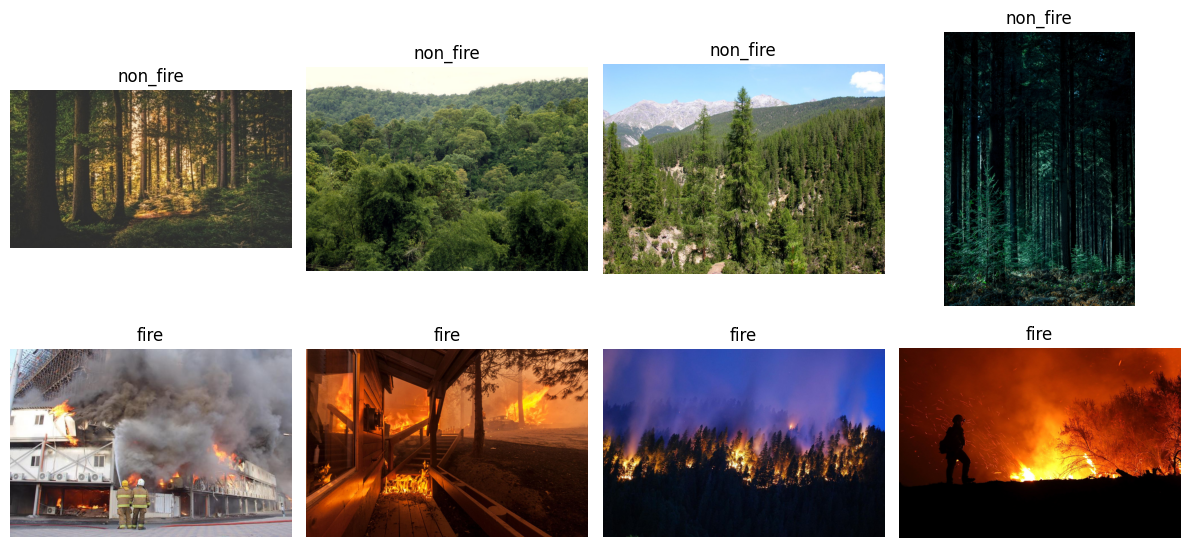

In [7]:
def show_samples(df, n_per_class=4):
    if len(df) == 0:
        print("No images available.")
        return
    fig, axes = plt.subplots(len(CLASSES), n_per_class, figsize=(3*n_per_class, 3*len(CLASSES)))
    for r, cls in enumerate(CLASSES):
        sample = df[df["class"] == cls].sample(min(n_per_class, len(df[df["class"] == cls])), random_state=SEED)
        for c, (_, row) in enumerate(sample.iterrows()):
            img = cv2.cvtColor(cv2.imread(row["path"]), cv2.COLOR_BGR2RGB)
            ax = axes[r, c] if len(CLASSES) > 1 else axes[c]
            ax.imshow(img)
            ax.set_title(cls)
            ax.axis("off")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "samples_per_class.png", dpi=120)
    plt.show()

show_samples(df)


## 4. Image Preprocessing Pipeline

The following operations are inspired directly by the literature review:

| Step | Purpose | Source in lit. review |
|------|---------|----------------------|
| **Resize to 224×224** | Standard CNN input; speeds up training | All CNN studies [1][2][3][4] |
| **Normalize [0, 1]** | Stabilizes gradient descent | Standard practice |
| **CLAHE (Adaptive Histogram Equalization)** | Boosts local contrast — flames stand out from dark backgrounds | Gonzalez & Woods [8] |
| **Gaussian blur (3×3)** | Removes high-frequency sensor noise | Zhang et al. [7]; Prakash et al. [2] |
| **Median filter (3×3)** | Removes salt-and-pepper noise while preserving flame edges | Zhang et al. [7] |
| **HSV conversion** | Hue isolates flame color independent of brightness | Celik & Demirel [5][10] |
| **RGB rule R>G>B** | Classical flame-pixel rule | Celik & Demirel [5]; Pritam & Dewan [12] |
| **Augmentation** | Synthetic robustness to lighting and orientation changes | Prakash et al. [2] |


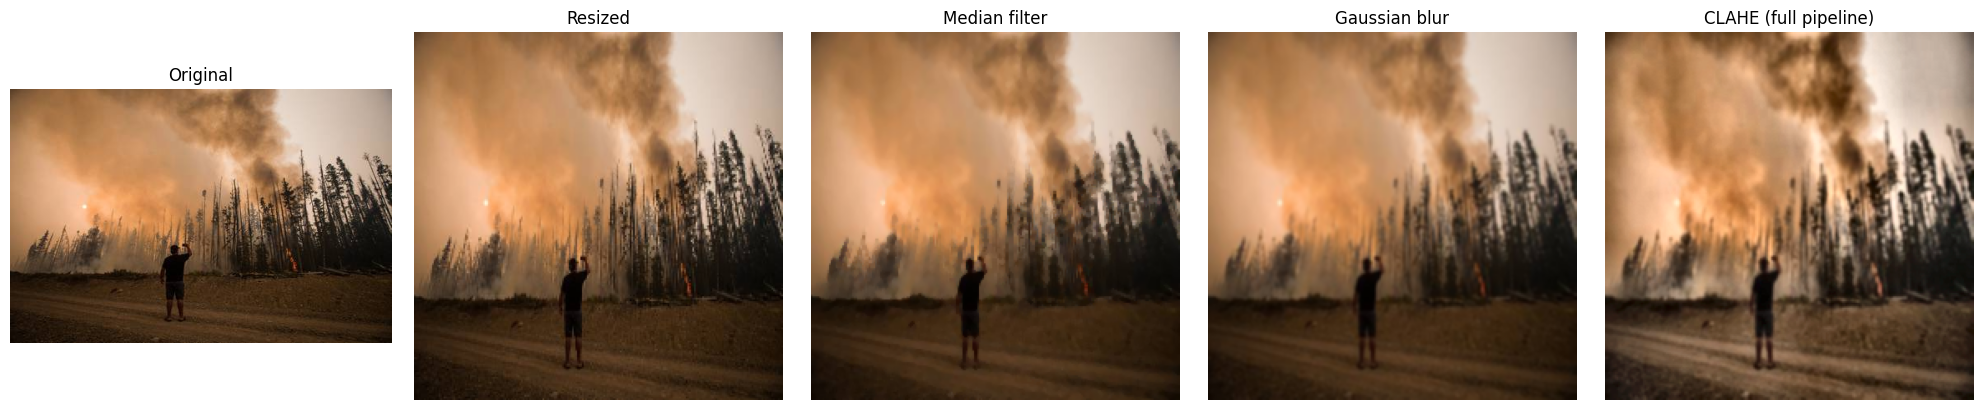

In [8]:
def preprocess_image(img_bgr, size=IMG_SIZE, apply_clahe=True,
                     apply_gaussian=True, apply_median=False):
    #Full preprocessing pipeline for a single image (BGR input from cv2.imread).Returns a float32 RGB array in [0, 1] of shape (size, size, 3).
   
    # 1) Resize -- uniform input
    img = cv2.resize(img_bgr, (size, size), interpolation=cv2.INTER_AREA)

    # 2) Noise reduction
    if apply_median:
        img = cv2.medianBlur(img, 3)            # good against salt-and-pepper noise
    if apply_gaussian:
        img = cv2.GaussianBlur(img, (3, 3), 0)  # mild low-pass filter

    # 3) Contrast enhancement via CLAHE on the L channel (Lab space preserves color)
    if apply_clahe:
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        l = clahe.apply(l)
        img = cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2BGR)

    # 4) BGR -> RGB, scale to [0, 1]
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    return img


def visualize_preprocessing(sample_path):
    img = cv2.imread(sample_path)
    if img is None:
        print("Could not load", sample_path); return

    steps = {
        "Original": cv2.cvtColor(img, cv2.COLOR_BGR2RGB),
        "Resized":  cv2.cvtColor(cv2.resize(img, (IMG_SIZE, IMG_SIZE)), cv2.COLOR_BGR2RGB),
        "Median filter": cv2.cvtColor(cv2.medianBlur(cv2.resize(img, (IMG_SIZE, IMG_SIZE)), 3), cv2.COLOR_BGR2RGB),
        "Gaussian blur": cv2.cvtColor(cv2.GaussianBlur(cv2.resize(img, (IMG_SIZE, IMG_SIZE)), (3, 3), 0), cv2.COLOR_BGR2RGB),
        "CLAHE (full pipeline)": (preprocess_image(img) * 255).astype(np.uint8),
    }
    fig, axes = plt.subplots(1, len(steps), figsize=(4*len(steps), 4))
    for ax, (name, im) in zip(axes, steps.items()):
        ax.imshow(im); ax.set_title(name); ax.axis("off")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "preprocessing_steps.png", dpi=120)
    plt.show()

if len(df) > 0:
    visualize_preprocessing(df.iloc[0]["path"])


## 5. Classical Image Processing Baseline (HSV + RGB rules)

Following Celik & Demirel [5][10] and Pritam & Dewan [12], we define rule-based flame and smoke detectors. They serve two roles:
- **Interpretable baseline** to compare against the CNN.
- **Fast pre-filter** for real-time inference — only frames flagged by the rules are passed to the CNN.

### 5.1 Flame color rules

**RGB rule:** A pixel is flame-like if
$$R > R_{\text{mean}} \quad \land \quad R > G > B \quad \land \quad S \geq \frac{(255 - R)\,S_{T}}{R_{\text{mean}}}$$

**HSV rule:** flame hue lies in $[0°, 50°]$, with high saturation and value:
$$0 \leq H \leq 50,\ S \geq 100,\ V \geq 100$$

### 5.2 Smoke rules
Smoke is low-saturation, mid-gray:
$$|R - G| \leq 15,\ |G - B| \leq 15,\ 80 \leq V \leq 220,\ S \leq 60$$

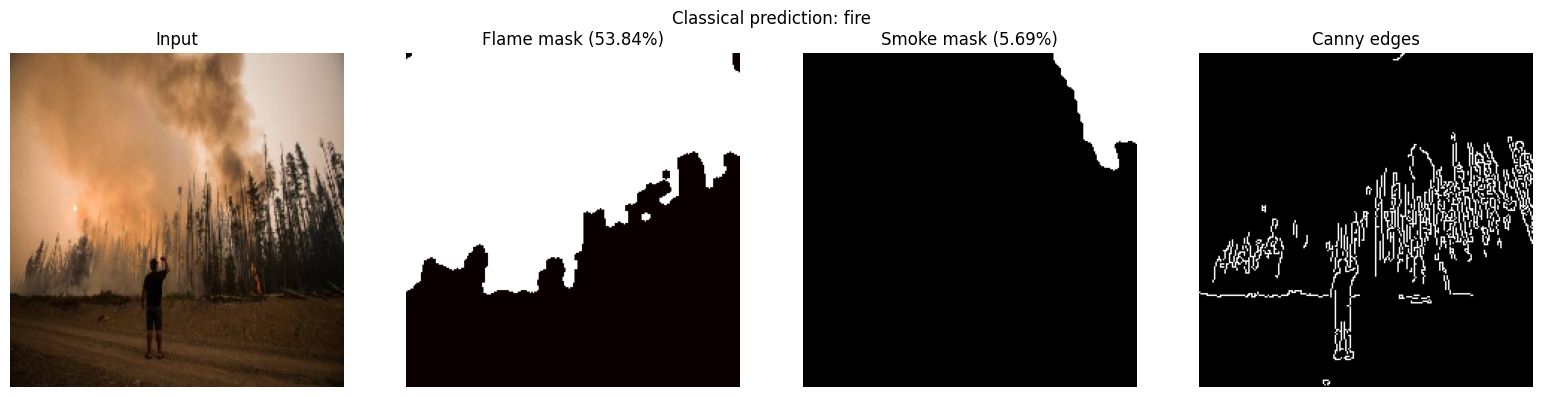

In [9]:
def flame_mask_hsv(img_bgr):
    #Return a binary mask of flame-like pixels using HSV rules.
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    lower = np.array([0,   100, 100], dtype=np.uint8)   # H, S, V lower
    upper = np.array([35,  255, 255], dtype=np.uint8)   # 0-35° = red-orange-yellow
    mask = cv2.inRange(hsv, lower, upper)
    return mask


def flame_mask_rgb(img_bgr):
    #Celik-style RGB rule: R > G > B, R > mean(R), high saturation.
    b, g, r = cv2.split(img_bgr)
    r_mean = r.mean()
    rule1 = (r > g) & (g > b)
    rule2 = r > r_mean
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    s = hsv[..., 1]
    S_T = 60
    rule3 = s >= ((255 - r.astype(np.int32)) * S_T // max(int(r_mean), 1))
    mask = (rule1 & rule2 & rule3).astype(np.uint8) * 255
    return mask


def smoke_mask(img_bgr):
    #Low-saturation, mid-gray pixels — characteristic of smoke.
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)
    mask = ((s <= 60) & (v >= 80) & (v <= 220)).astype(np.uint8) * 255
    return mask


def morphological_clean(mask, kernel_size=5):
    #Open then close to remove specks and fill small holes.
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k)
    return mask


def classical_detect(img_bgr, fire_pixel_threshold=0.005):
    #Rule-based fire/smoke detector. Returns dict of masks + predicted label.
    # fire_pixel_threshold: fraction of fire pixels needed to flag the image.
    
    flame_hsv = flame_mask_hsv(img_bgr)
    flame_rgb = flame_mask_rgb(img_bgr)
    flame = cv2.bitwise_or(flame_hsv, flame_rgb)
    flame = morphological_clean(flame)

    smoke = morphological_clean(smoke_mask(img_bgr), kernel_size=7)

    total_pixels = img_bgr.shape[0] * img_bgr.shape[1]
    fire_ratio  = (flame > 0).sum() / total_pixels
    smoke_ratio = (smoke > 0).sum() / total_pixels

    if fire_ratio > fire_pixel_threshold:
        label = "fire"
    elif smoke_ratio > 0.20:    # smoke usually covers a large area
        label = "smoke"
    else:
        label = "non_fire"

    return {
        "flame_mask": flame, "smoke_mask": smoke,
        "fire_ratio": fire_ratio, "smoke_ratio": smoke_ratio,
        "label": label,
    }


def show_classical_pipeline(img_path):
    img = cv2.imread(img_path)
    if img is None: return
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    out = classical_detect(img)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 100, 200)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); axes[0].set_title("Input")
    axes[1].imshow(out["flame_mask"], cmap="hot");        axes[1].set_title(f"Flame mask ({out['fire_ratio']*100:.2f}%)")
    axes[2].imshow(out["smoke_mask"], cmap="gray");       axes[2].set_title(f"Smoke mask ({out['smoke_ratio']*100:.2f}%)")
    axes[3].imshow(edges, cmap="gray");                   axes[3].set_title("Canny edges")
    for ax in axes: ax.axis("off")
    plt.suptitle(f"Classical prediction: {out['label']}")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "classical_pipeline.png", dpi=120)
    plt.show()

if len(df) > 0:
    fire_sample = df[df["class"] == "fire"].iloc[0]["path"] if "fire" in df["class"].values else df.iloc[0]["path"]
    show_classical_pipeline(fire_sample)


## 6. Data Splitting and Augmentation

We use a stratified 70/15/15 train/val/test split. Augmentation is only applied to the training set.

In [10]:
def stratified_split(df, val_size=VALIDATION_SPLIT, test_size=TEST_SPLIT, seed=SEED):
    train_df, temp_df = train_test_split(df, test_size=val_size+test_size,
                                         stratify=df["label"], random_state=seed)
    val_df, test_df = train_test_split(temp_df, test_size=test_size/(val_size+test_size),
                                       stratify=temp_df["label"], random_state=seed)
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)

if len(df) > 0:
    train_df, val_df, test_df = stratified_split(df)
    print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")


Train: 699 | Val: 150 | Test: 150


In [11]:
# tf.data pipeline -- efficient, uses preprocess_image() from section 4

def _load_and_preprocess(path, label):
    def _py(p):
        img = cv2.imread(p.decode())
        if img is None:
            return np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)
        return preprocess_image(img).astype(np.float32)
    img = tf.numpy_function(_py, [path], tf.float32)
    img.set_shape((IMG_SIZE, IMG_SIZE, 3))
    return img, label


def _augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, max_delta=0.15)
    img = tf.image.random_contrast(img, 0.85, 1.15)
    img = tf.image.random_saturation(img, 0.85, 1.15)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label


def make_dataset(df_split, training=False, batch_size=BATCH_SIZE):
    paths = df_split["path"].values.astype(str)
    labels = df_split["label"].values.astype(np.int32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(2048, seed=SEED)
    ds = ds.map(_load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.map(_augment, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


if len(df) > 0:
    train_ds = make_dataset(train_df, training=True)
    val_ds   = make_dataset(val_df, training=False)
    test_ds  = make_dataset(test_df, training=False)
    print("Datasets ready.")


Datasets ready.


## 7. CNN Models

We provide four options. Set `BACKBONE` in the config cell.

### 7.1 Custom CNN (from scratch)
A compact 4-block CNN. Useful as a baseline and to demonstrate the layer-by-layer process taught in class.

### 7.2 Transfer learning backbones
- **MobileNetV2** — ~3.5M params, designed for mobile/edge devices. **Recommended for this project.**
- **ResNet50** — ~25M params, strong but heavier.
- **EfficientNetB0** — ~5M params, often best accuracy-to-size ratio.

> **Why MobileNetV2 is the recommended default**: ARTI 404 is a one-semester course with limited compute. MobileNetV2 trains in minutes on Colab GPU, achieves competitive accuracy (literature reports 95%+ on similar datasets), and the small footprint means the resulting model can be deployed on a Raspberry Pi or smartphone — directly addressing the "lightweight architectures" trend noted in study [3].

In [12]:
def build_custom_cnn(input_shape=(IMG_SIZE, IMG_SIZE, CHANNELS), num_classes=NUM_CLASSES):
    #4-block CNN: Conv-BN-ReLU-Pool x 4 + GAP + Dense + Softmax.
    inp = layers.Input(shape=input_shape)
    x = inp
    for filters in (32, 64, 128, 256):
        x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.MaxPooling2D(2)(x)
        x = layers.Dropout(0.25)(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    return models.Model(inp, out, name="custom_cnn")


def build_transfer_model(backbone_name="mobilenetv2", input_shape=(IMG_SIZE, IMG_SIZE, CHANNELS),
                        num_classes=NUM_CLASSES, trainable_top=False):
    bb_map = {
        "mobilenetv2":    MobileNetV2,
        "resnet50":       ResNet50,
        "efficientnetb0": EfficientNetB0,
    }
    if backbone_name not in bb_map:
        raise ValueError(f"Unknown backbone {backbone_name}")
    base = bb_map[backbone_name](include_top=False, weights="imagenet", input_shape=input_shape)
    base.trainable = trainable_top  # freeze for stage 1
    inp = layers.Input(shape=input_shape)
    x = base(inp, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    return models.Model(inp, out, name=f"{backbone_name}_transfer"), base


def build_model():
    if BACKBONE == "custom":
        m = build_custom_cnn(); base = None
    else:
        m, base = build_transfer_model(BACKBONE)
    m.compile(optimizer=optimizers.Adam(LEARNING_RATE),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
    return m, base


model, base = build_model()
model.summary()


Model: "mobilenetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 8. Training Loop

Two stages when using transfer learning:
1. **Frozen backbone** — only the classifier head learns. Quick and stable.
2. **Fine-tune** — unfreeze the top ~30 layers of the backbone with a small learning rate.

Callbacks:
- `ModelCheckpoint` — save best-val-accuracy weights.
- `EarlyStopping` — stop if val loss does not improve for 6 epochs.
- `ReduceLROnPlateau` — halve LR when val loss plateaus.

In [13]:
def class_weights_from_labels(labels):
    #Inverse-frequency class weights for imbalanced data.
    counts = np.bincount(labels)
    total = counts.sum()
    return {i: total / (len(counts) * c) for i, c in enumerate(counts)}


def train_model(model, train_ds, val_ds, train_labels, model_name, epochs=EPOCHS):
    cw = class_weights_from_labels(train_labels)
    print("Class weights:", cw)
    ckpt_path = MODEL_DIR / f"{model_name}_best.keras"
    cbs = [
        callbacks.ModelCheckpoint(str(ckpt_path), monitor="val_accuracy",
                                  save_best_only=True, mode="max"),
        callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
        callbacks.CSVLogger(str(OUTPUT_DIR / f"{model_name}_history.csv")),
    ]
    hist = model.fit(train_ds, validation_data=val_ds, epochs=epochs,
                     class_weight=cw, callbacks=cbs, verbose=1)
    return hist, ckpt_path


# --- Uncomment to actually train (requires data) ---
if len(df) > 0:
 history, ckpt = train_model(model, train_ds, val_ds, train_df["label"].values, BACKBONE)


Class weights: {0: np.float64(2.043859649122807), 1: np.float64(0.6619318181818182)}
Epoch 1/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 250ms/step - accuracy: 0.6094 - loss: 0.7740 - val_accuracy: 0.8333 - val_loss: 0.3882 - learning_rate: 1.0000e-04
Epoch 2/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 209ms/step - accuracy: 0.8069 - loss: 0.4578 - val_accuracy: 0.8733 - val_loss: 0.3098 - learning_rate: 1.0000e-04
Epoch 3/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 214ms/step - accuracy: 0.8541 - loss: 0.3510 - val_accuracy: 0.8867 - val_loss: 0.2650 - learning_rate: 1.0000e-04
Epoch 4/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 212ms/step - accuracy: 0.8884 - loss: 0.2979 - val_accuracy: 0.8867 - val_loss: 0.2592 - learning_rate: 1.0000e-04
Epoch 5/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 201ms/step - accuracy: 0.9170 - loss: 0.2320 - val_accuracy: 0.8933 - val_loss: 0.2359 - learning_rate: 1.0000e-04
Epoch 6/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 217ms/step - accuracy: 0.9099 - loss: 0.2379 - val_accuracy: 0.9000 - val_loss: 0.2267 - learn

### 8.1 Fine-tuning (transfer learning only)

In [14]:
def finetune(model, base, train_ds, val_ds, train_labels, model_name,
             unfreeze_from=-30, epochs=10, lr=1e-5):
    if base is None:
        print("Custom model — nothing to fine-tune."); return None, None
    base.trainable = True
    for layer in base.layers[:unfreeze_from]:
        layer.trainable = False
    model.compile(optimizer=optimizers.Adam(lr),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    print(f"Fine-tuning last {abs(unfreeze_from)} layers @ lr={lr}")
    return train_model(model, train_ds, val_ds, train_labels, model_name + "_ft", epochs=epochs)

if len(df) > 0:
     ft_history, ft_ckpt = finetune(model, base, train_ds, val_ds, train_df["label"].values, BACKBONE)


Fine-tuning last 30 layers @ lr=1e-05
Class weights: {0: np.float64(2.043859649122807), 1: np.float64(0.6619318181818182)}
Epoch 1/10


22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 246ms/step - accuracy: 0.9242 - loss: 0.1929 - val_accuracy: 0.9267 - val_loss: 0.1544 - learning_rate: 1.0000e-05
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 218ms/step - accuracy: 0.9256 - loss: 0.1968 - val_accuracy: 0.9267 - val_loss: 0.1543 - learning_rate: 1.0000e-05
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 211ms/step - accuracy: 0.9413 - loss: 0.1548 - val_accuracy: 0.9267 - val_loss: 0.1578 - learning_rate: 1.0000e-05
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 215ms/step - accuracy: 0.9542 - loss: 0.1335 - val_accuracy: 0.9267 - val_loss: 0.1608 - learning_rate: 1.0000e-05
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step - accuracy: 0.9399 - loss: 0.1595 - val_accuracy: 0.9267 - val_loss: 0.1634 - learning_rate: 5.0000e-06
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 211ms/step - accuracy: 0.9599 - loss: 0.1224 - val_accuracy: 0.9267 - val_loss: 0.1634 - learning_rate: 5.0000e-06
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 210ms/step - accuracy: 0.9628 - lo

### 8.2 Training curves

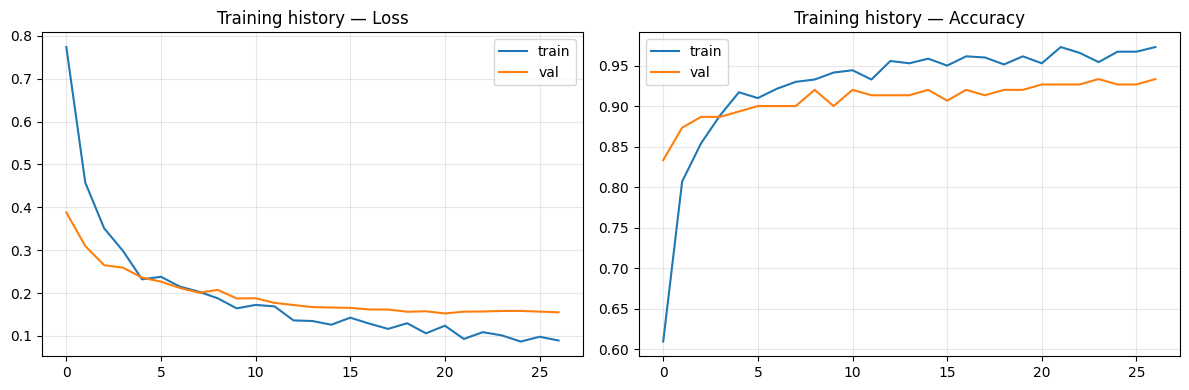

In [15]:
def plot_history(history, title="Training history"):
    if history is None: return
    h = history.history
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(h["loss"], label="train"); axes[0].plot(h["val_loss"], label="val")
    axes[0].set_title(f"{title} — Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(h["accuracy"], label="train"); axes[1].plot(h["val_accuracy"], label="val")
    axes[1].set_title(f"{title} — Accuracy"); axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "training_curves.png", dpi=120)
    plt.show()

plot_history(history)


## 9. Evaluation

### Why recall matters most in fire detection
A **false negative** (missed fire) can cost lives — the model says "no fire" when there is one. A **false positive** (false alarm) is annoying but recoverable. We therefore optimize for **high recall on the fire class**, accepting some precision loss. This is reflected in our preference for the macro F1 score and per-class recall reporting.

$$\text{Recall}_{\text{fire}} = \frac{TP_{\text{fire}}}{TP_{\text{fire}} + FN_{\text{fire}}}$$


=== Classification report ===
              precision    recall  f1-score   support

    non_fire     0.8947    0.9189    0.9067        37
        fire     0.9732    0.9646    0.9689       113

    accuracy                         0.9533       150
   macro avg     0.9340    0.9418    0.9378       150
weighted avg     0.9539    0.9533    0.9535       150



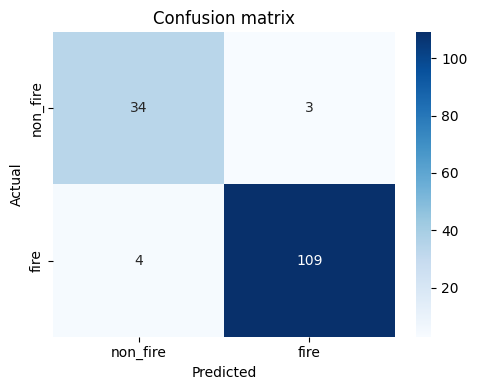

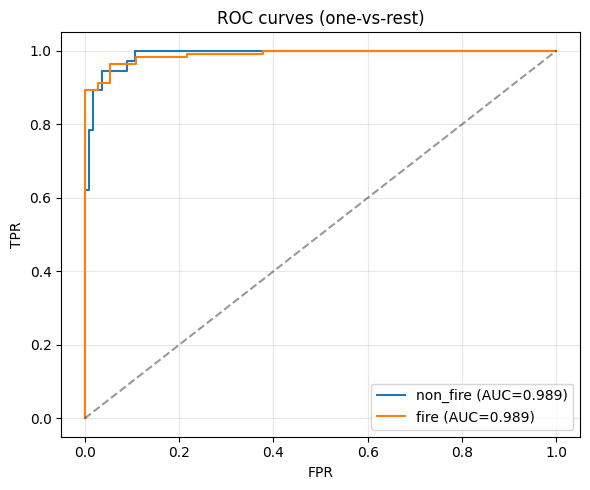

In [16]:
def evaluate_model(model, test_ds, test_df):
    y_true, y_pred, y_prob = [], [], []
    for X, y in test_ds:
        p = model.predict(X, verbose=0)
        y_prob.extend(p)
        y_pred.extend(p.argmax(axis=1))
        y_true.extend(y.numpy())
    y_true = np.array(y_true); y_pred = np.array(y_pred); y_prob = np.array(y_prob)

    print("\n=== Classification report ===")
    print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title("Confusion matrix"); plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "confusion_matrix.png", dpi=120)
    plt.show()

    # ROC (one-vs-rest)
    plt.figure(figsize=(6, 5))
    for i, cls in enumerate(CLASSES):
        bin_true = (y_true == i).astype(int)
        fpr, tpr, _ = roc_curve(bin_true, y_prob[:, i])
        plt.plot(fpr, tpr, label=f"{cls} (AUC={auc(fpr, tpr):.3f})")
    plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
    plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC curves (one-vs-rest)")
    plt.legend(); plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "roc_curves.png", dpi=120)
    plt.show()

    return y_true, y_pred, y_prob

y_true, y_pred, y_prob = evaluate_model(model, test_ds, test_df)


### 9.1 Comparison with the classical baseline

We score the rule-based detector on the same test set so the paper can present a head-to-head comparison.

In [17]:
def evaluate_classical(test_df):
    if len(test_df) == 0: return None
    y_true, y_pred = [], []
    label_to_idx = {c: i for i, c in enumerate(CLASSES)}
    for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Classical eval"):
        img = cv2.imread(row["path"])
        if img is None: continue
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        pred = classical_detect(img)["label"]
        y_pred.append(label_to_idx.get(pred, 0))
        y_true.append(row["label"])
    print("\n=== Classical baseline classification report ===")
    print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))
    return np.array(y_true), np.array(y_pred)

y_true_c, y_pred_c = evaluate_classical(test_df)


Classical eval: 100%|██████████| 150/150 [00:01<00:00, 105.12it/s]


=== Classical baseline classification report ===
              precision    recall  f1-score   support

    non_fire     1.0000    0.5676    0.7241        37
        fire     0.8760    1.0000    0.9339       113

    accuracy                         0.8933       150
   macro avg     0.9380    0.7838    0.8290       150
weighted avg     0.9066    0.8933    0.8821       150



## 10. Inference and Real-Time Detection

### 10.1 Single image

In [18]:
def predict_image(model, img_path):
    img = cv2.imread(img_path)
    if img is None:
        return None
    x = preprocess_image(img)
    p = model.predict(x[None, ...], verbose=0)[0]
    return {CLASSES[i]: float(p[i]) for i in range(NUM_CLASSES)}, CLASSES[int(p.argmax())]

probs, label = predict_image(model, "data/test/sample.png")
print(label, probs)


non_fire {'non_fire': 0.5109739303588867, 'fire': 0.48902612924575806}


### 10.2 Real-time webcam / video detection (bonus)

Run this cell in a local Python session (not inside Colab) and press **q** to quit. The classical pre-filter is checked first; only frames with a positive flame-mask are sent through the CNN, saving ~80% of inference cost.

In [19]:
def realtime_detect(model_path, source=0, every_n=2):
    #Live fire detection. `source` can be a webcam index or a video file path.
    model_local = tf.keras.models.load_model(model_path)
    cap = cv2.VideoCapture(source)
    if not cap.isOpened():
        print("Could not open video source"); return

    frame_idx = 0
    last_label, last_prob = "non_fire", 0.0
    while True:
        ok, frame = cap.read()
        if not ok: break
        frame_idx += 1
        run_cnn = (frame_idx % every_n == 0)

        # Classical pre-filter
        cls_out = classical_detect(cv2.resize(frame, (IMG_SIZE, IMG_SIZE)))
        flagged = cls_out["label"] != "non_fire"

        if run_cnn and flagged:
            x = preprocess_image(frame)
            p = model_local.predict(x[None, ...], verbose=0)[0]
            last_label = CLASSES[int(p.argmax())]
            last_prob  = float(p.max())

        color = (0, 0, 255) if last_label == "fire" else (0, 165, 255) if last_label == "smoke" else (0, 255, 0)
        cv2.putText(frame, f"{last_label.upper()} {last_prob:.2f}", (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, color, 2)
        cv2.imshow("Fire/Smoke Detection", frame)
        if cv2.waitKey(1) & 0xFF == ord("q"):
            break
    cap.release(); cv2.destroyAllWindows()

realtime_detect(MODEL_DIR / "mobilenetv2_best.keras", source=0)


KeyboardInterrupt: 

## 11. Save the Final Model

The Keras `.keras` format saves architecture + weights + optimizer state in a single file. For deployment on edge devices, convert to TFLite.

In [20]:
model.save(MODEL_DIR / "fire_detector_final.keras")
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()
(MODEL_DIR / "fire_detector_final.tflite").write_bytes(tflite_model)
print("Saved Keras and TFLite models.")


INFO:tensorflow:Assets written to: C:\Users\user\AppData\Local\Temp\tmpzkis53i8\assets


INFO:tensorflow:Assets written to: C:\Users\user\AppData\Local\Temp\tmpzkis53i8\assets


Saved artifact at 'C:\Users\user\AppData\Local\Temp\tmpzkis53i8'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  2898662550864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2898997702160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2898698003920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2898662553360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2898997702544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2898662549520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2898698004112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2898698004880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2898698004496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2898698003536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  28

---

## End of notebook

**Next steps:**
1. Download the Kaggle fire dataset and extract under `data/fire_dataset/`.
2.DOWNLOAD the requirment libraries found in requirments.txt file
3. Run cells top-to-bottom. On VS, switch runtime to **GPU** for ~10x speedup.
4. Inspect `outputs/figures/` for plots to include in the paper.
5. The best model is saved under `outputs/models/` — load it for the demo.

For the live webcam demo, run the script `src/realtime.py` provided , not the notebook (Jupyter cannot open OpenCV windows on Colab).
